# Temporal Embedding Probe — LabTube MIMIC-IV Dataset

Two probing experiments on **per-slot temporal embeddings** `(N, T=12, D=192)` extracted  
from the **LabTube held-out test set** (17,555 ICU admissions).

This is an unbiased probe on **unseen data** — patients are NOT selected by lab extremity.  
Lab values are decoded back from the normalised grid channels using stored mean/std.

**Test 1 — Regression probes per time step**  
- For each lab and each temporal slot `t` (1 h … 24 h from admission):  
  - **Ridge regression**: embedding → continuous lab value (R², 5-fold CV)  
  - **Logistic regression**: embedding → Q1 vs Q4 label derived from data (AUC, 5-fold CV)

**Test 2 — PCA latent-space structure**  
- Pool time-averaged embeddings across all labs, run PCA.  
- Spearman correlation between each PC and each lab's continuous value.  
- Repeat per time slot to track how PC–lab alignment evolves over 96 h.

**Data source**: `data_embedding/labtube_dataset.npz`  
**Labs**: hematocrit, hemoglobin, creatinine, sodium, potassium, bicarbonate,  
         lactate, AST, total bilirubin, glucose, troponin-T, WBC

## 0. Setup and imports

In [23]:
import sys, io, json
from pathlib import Path

ROOT    = Path(".").resolve().parent
SCRIPTS = ROOT / "scripts"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import torch
from scipy import stats as sp_stats
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

DEVICE  = "cuda" if torch.cuda.is_available() else "cpu"
SEED    = 42
RNG     = np.random.default_rng(SEED)

DATASET_NPZ = ROOT / "data_embedding" / "labtube_dataset.npz"
MODEL_CKPT  = ROOT / "data_embedding" / "modeB_best.pt"
OUT_DIR     = ROOT / "results" / "temporal_probe"
CACHE_TEMB  = OUT_DIR / "labtube_temporal_embeddings.npz"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Temporal slot config — must match model training (window=96h, bin=4h, anchor=admittime)
T_SLOTS   = 12
BIN_H     = 1.0
TC_T      = np.array([(2 * t + 1) * BIN_H for t in range(T_SLOTS)])  # [4, 12, ..., 92] h

N_CV_SPLITS = 5
N_PCS       = 15

print(f"Device  : {DEVICE}")
print(f"OUT_DIR : {OUT_DIR}")
print(f"Slot centres (h from admit): {TC_T.tolist()}")

Device  : cuda
OUT_DIR : /mnt/nvme2tb/krittaphas/LabTube/results/temporal_probe
Slot centres (h from admit): [1.0, 3.0, 5.0, 7.0, 9.0, 11.0, 13.0, 15.0, 17.0, 19.0, 21.0, 23.0]


## 1. Load dataset and extract temporal embeddings

In [24]:
# ── Load metadata ─────────────────────────────────────────────────────────────
print("Loading dataset NPZ metadata...")
npz         = np.load(DATASET_NPZ, allow_pickle=True)
grid_layout = json.loads(npz["meta_grid_layout_json"].tobytes().decode())
norm_stats  = json.loads(npz["meta_norm_stats_json"].tobytes().decode())
split_info  = json.loads(npz["meta_split_json"].tobytes().decode())
labels_df   = pd.read_csv(io.StringIO(npz["meta_labels_csv"].tobytes().decode()))

# Lookup maps
itemid_to_rc    = {e["itemid"]: (e["row"], e["col"]) for e in grid_layout}
itemid_to_label = {e["itemid"]: e["label"]           for e in grid_layout}
norm_by_itemid  = {e["itemid"]: e                    for e in norm_stats["labs"]}

print(f"Admissions: {len(labels_df):,}  |  Grid: {len(grid_layout)} labs  |  "
      f"Train: {len(split_info['train']):,}  |  Test: {len(split_info['test']):,}")

Loading dataset NPZ metadata...
Admissions: 87,772  |  Grid: 64 labs  |  Train: 61,439  |  Test: 17,555


In [25]:
# ── Lab catalogue ─────────────────────────────────────────────────────────────
LAB_NAMES_ORDERED = [
    "hematocrit", 
    "hemoglobin", 
    "creatinine", 
    "sodium",
    "potassium",  
    "bicarbonate", 
    "lactate",   
    "ast",
    "tb",         
    "glucose",    
    "trop_t",    
    "wbc",
]
LAB_ITEMIDS = {
    "hematocrit": 51221, "hemoglobin": 51222, "creatinine": 50912,
    "sodium":     50983, "potassium":  50971, "bicarbonate": 50882,
    "lactate":    50813, "ast":        50878, "tb":         50885,
    "glucose":    50931, "trop_t":     51003, "wbc":        51301,
}

QUARTILE_STATES = ["q1", "q2", "q3", "q4"]

for name in LAB_NAMES_ORDERED:
    iid = LAB_ITEMIDS[name]
    rc  = itemid_to_rc.get(iid)
    ns  = norm_by_itemid.get(iid, {})
    print(f"  {name:<14} itemid={iid}  grid={rc}  "
          f"mean={ns.get('mean', float('nan')):.3f}  std={ns.get('std', float('nan')):.3f}")

  hematocrit     itemid=51221  grid=(3, 2)  mean=33.011  std=6.453
  hemoglobin     itemid=51222  grid=(3, 3)  mean=10.903  std=2.262
  creatinine     itemid=50912  grid=(1, 4)  mean=0.781  std=0.378
  sodium         itemid=50983  grid=(2, 4)  mean=138.403  std=5.391
  potassium      itemid=50971  grid=(2, 3)  mean=4.164  std=0.665
  bicarbonate    itemid=50882  grid=(0, 6)  mean=23.601  std=4.607
  lactate        itemid=50813  grid=(0, 0)  mean=2.585  std=2.420
  ast            itemid=50878  grid=(0, 5)  mean=3.845  std=1.175
  tb             itemid=50885  grid=(0, 7)  mean=0.690  std=0.601
  glucose        itemid=50931  grid=(1, 6)  mean=135.265  std=70.045
  trop_t         itemid=51003  grid=(2, 5)  mean=0.347  std=0.502
  wbc            itemid=51301  grid=(5, 0)  mean=2.327  std=0.507


In [26]:
# ── Build video dict (TEST split only) ───────────────────────────────────────
# Cap at MAX_VIDS for faster iteration; set to None to use all ~17k test videos
MAX_VIDS = None   # use full test set

test_ids  = set(split_info["test"])
vid_keys  = [k for k in npz.keys() if k.startswith("vid_") and
             int(k.split("_")[1]) in test_ids]
if MAX_VIDS:
    vid_keys = list(RNG.choice(vid_keys, min(MAX_VIDS, len(vid_keys)), replace=False))

video_dict = {int(k.split("_")[1]): npz[k] for k in tqdm(vid_keys, desc="Loading videos")}
print(f"\nLoaded {len(video_dict):,} test videos  |  shape: {next(iter(video_dict.values())).shape}")

Loading videos: 100%|██████████| 17555/17555 [00:01<00:00, 17545.50it/s]


Loaded 17,555 test videos  |  shape: (24, 8, 8)


In [27]:
# ── Run model and extract temporal embeddings (cached) ───────────────────────
from lab_delta_experiment import extract_temporal_embeddings
from lab_state_experiment  import load_model

N_FRAMES = 24
model    = load_model(n_frames=N_FRAMES, ckpt_path=MODEL_CKPT)
print(f"Model loaded on {DEVICE}")

# if CACHE_TEMB.exists():
#     cached = np.load(CACHE_TEMB)
#     temporal_embs = cached["temporal_embs"]   # (N, 12, 192)
#     all_hadm_ids  = cached["hadm_ids"].tolist()
#     print(f"Loaded cached embeddings: {temporal_embs.shape}")
# else:
temporal_embs, all_hadm_ids = extract_temporal_embeddings(model, video_dict, batch_size=64)
# np.savez_compressed(CACHE_TEMB, temporal_embs=temporal_embs, hadm_ids=np.array(all_hadm_ids))
# print(f"Saved: {temporal_embs.shape}")

N, T, D = temporal_embs.shape
hadm_to_idx = {hid: i for i, hid in enumerate(all_hadm_ids)}
print(f"Shape: (N={N}, T={T}, D={D})  |  T_centres: {TC_T.tolist()}")

Model loaded on cuda


Extracting temporal embeddings: 100%|██████████| 275/275 [00:02<00:00, 113.88it/s]

Shape: (N=17555, T=12, D=192)  |  T_centres: [1.0, 3.0, 5.0, 7.0, 9.0, 11.0, 13.0, 15.0, 17.0, 19.0, 21.0, 23.0]


## 2. Decode lab values from video grid and build per-lab datasets

In [28]:
def extract_lab_values_from_videos(video_dict, hadm_ids_ordered, itemid,
                                     norm_by_itemid):
    """
    Extract a single lab's time-averaged normalised value from each video,
    then invert normalisation to get raw units.

    Returns (valid_indices, raw_values, temb_subset) where only admissions
    with ≥1 non-NaN observation for this lab are included.
    """
    ns  = norm_by_itemid[itemid]
    row, col = itemid_to_rc[itemid]
    mean_v, std_v = float(ns["mean"]), float(ns["std"])

    valid_idx, raw_vals, hadm_idx = [], [], []
    for i, hid in enumerate(hadm_ids_ordered):
        vid = video_dict.get(hid)       # (24, 8, 8) or None
        if vid is None:
            continue
        channel = vid[:, row, col]      # (24,) normalised, NaN=missing
        observed = channel[np.isfinite(channel)]
        if len(observed) == 0:
            continue
        norm_mean = observed.mean()
        raw_val   = norm_mean * std_v + mean_v   # back to original units
        valid_idx.append(i)
        raw_vals.append(raw_val)
        hadm_idx.append(hid)
        
    valid_idx = np.array(valid_idx)
    raw_vals  = np.array(raw_vals)
    hadm_idx = np.array(hadm_idx)

    return valid_idx, raw_vals,  temporal_embs[valid_idx], hadm_idx


labs = []
for name in LAB_NAMES_ORDERED:
    iid         = LAB_ITEMIDS[name]
    idx, vals, temb_sub, hadm_ids = extract_lab_values_from_videos(
        video_dict, all_hadm_ids, iid, norm_by_itemid
    )

    if len(idx) < 200:
        print(f"  {name:<14} SKIP — only {len(idx)} valid admissions")
        continue

    # Q1/Q4 labels derived from data quartiles
    q25, q75 = np.percentile(vals, [25, 75])
    q1_mask  = vals <= q25
    q4_mask  = vals >= q75

    lab = {
        "name":     name,
        "display":  itemid_to_label[iid],
        "valid_idx": idx,                # indices of valid admissions (into temporal_embs)
        "all_temb": temb_sub,           # (M, 12, 192) — all valid admissions
        "all_val":  vals,               # (M,) raw lab values
        "all_rank": pd.cut(vals, bins=[-np.inf, q25, np.median(vals), q75, np.inf],
                           labels=[0, 1, 2, 3]).astype(int),
        "q1_temb":  temb_sub[q1_mask],  # bottom quartile
        "q4_temb":  temb_sub[q4_mask],  # top quartile
        "q1_val":   vals[q1_mask],
        "q4_val":   vals[q4_mask],
        "hadm_ids": hadm_ids,            # IDs of valid admissions
    }
    labs.append(lab)
    print(f"  {name:<14} n={len(idx):>5}  Q1={q1_mask.sum():>4}  Q4={q4_mask.sum():>4}  "
          f"val=[{vals.min():.2f}, {vals.max():.2f}]  "
          f"q25={q25:.2f}  q75={q75:.2f}")

n_labs = len(labs)
print(f"\n{n_labs} labs ready.")

  hematocrit     n=17129  Q1=4297  Q4=4307  val=[13.40, 68.10]  q25=29.55  q75=38.40
  hemoglobin     n=16993  Q1=4364  Q4=4259  val=[4.30, 21.70]  q25=9.60  q75=12.70
  creatinine     n=17081  Q1=4658  Q4=4314  val=[0.10, 3.21]  q25=0.53  q75=0.81
  sodium         n=16708  Q1=4188  Q4=5078  val=[107.60, 173.50]  q25=136.33  q75=141.00
  potassium      n=16847  Q1=5014  Q4=4666  val=[2.10, 9.95]  q25=3.80  q75=4.40
  bicarbonate    n=16807  Q1=5300  Q4=5472  val=[5.00, 48.00]  q25=22.00  q75=26.00
  lactate        n= 5508  Q1=1379  Q4=1398  val=[0.40, 26.64]  q25=1.25  q75=2.40
  ast            n= 8628  Q1=2373  Q4=2163  val=[1.79, 9.80]  q25=3.00  q75=4.16
  tb             n= 8219  Q1=2890  Q4=2060  val=[0.00, 3.95]  q25=0.34  q75=0.72
  glucose        n=16537  Q1=4181  Q4=4173  val=[10.00, 831.00]  q25=96.00  q75=143.00
  trop_t         n= 2903  Q1= 733  Q4= 726  val=[0.01, 3.14]  q25=0.03  q75=0.31
  wbc            n=16999  Q1=4352  Q4=4250  val=[0.10, 5.65]  q25=2.00  q75=2.56

12 

## Test 1 — Regression Probes per Temporal Slot

At each of the 12 time slots:
- **Linear probe** (Ridge regression): can the embedding predict the continuous lab value?  
- **Logistic probe** (Logistic regression, Q1 vs Q4): can it distinguish low from high?  

Both use 5-fold cross-validation.

In [29]:
from sklearn.model_selection import cross_val_score, cross_validate

def linear_probe_over_time(all_temb: np.ndarray, all_val: np.ndarray,
                            n_splits: int = N_CV_SPLITS) -> np.ndarray:
    """
    For each temporal slot t, fit 5-fold Ridge regression.
    Returns R²(T,) array.
    """
    n, T, D = all_temb.shape
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)

    r2_t    = np.zeros(T)
    coefs_t = np.zeros((T, D))

    for t in range(T):
        pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
        out = cross_validate(
            pipe, all_temb[:, t, :], all_val,
            cv=kf, scoring="r2", return_estimator=True,
        )
        r2_t[t] = out["test_score"].mean()
        # average coefficients across folds
        fold_coefs = np.stack([est.named_steps["ridge"].coef_ for est in out["estimator"]])
        coefs_t[t] = fold_coefs.mean(axis=0)

    return r2_t, coefs_t


def logistic_probe_over_time(q1_temb: np.ndarray, q4_temb: np.ndarray,
                             n_splits: int = N_CV_SPLITS):
    """
    For each temporal slot t, fit 5-fold Logistic regression (Q1 vs Q4).
    Returns AUC(T,) array and coefficients(T, D) array averaged across folds.
    """
    T  = q1_temb.shape[1]
    D  = q1_temb.shape[2]
    N1 = len(q1_temb)
    N4 = len(q4_temb)
    y  = np.array([0] * N1 + [1] * N4)

    skf     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    auc_t   = np.zeros(T)
    coefs_t = np.zeros((T, D))

    for t in range(T):
        X = np.vstack([q1_temb[:, t, :], q4_temb[:, t, :]])
        pipe = make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=500, C=1.0, solver="lbfgs"),
        )

        out = cross_validate(
            pipe, X, y,
            cv=skf,
            scoring="roc_auc",
            return_estimator=True,
        )
        auc_t[t] = out["test_score"].mean()

        # Average coefficients across folds
        fold_coefs = np.stack([
            est.named_steps["logisticregression"].coef_.ravel()
            for est in out["estimator"]
        ])
        coefs_t[t] = fold_coefs.mean(axis=0)

    return auc_t, coefs_t

print("Running regression probes (this may take a few minutes)...")
for lab in tqdm(labs, desc="Labs"):
    lab["r2_t"],  lab["ridge_coefs_t"]    = linear_probe_over_time(
        lab["all_temb"], lab["all_val"]
    )
    lab["auc_t"], lab["logistic_coefs_t"] = logistic_probe_over_time(
        lab["q1_temb"], lab["q4_temb"]
    )
    print(f"  {lab['name']:15s}  max R²={lab['r2_t'].max():.3f} @ slot {lab['r2_t'].argmax()}  "
          f"max AUC={lab['auc_t'].max():.3f} @ slot {lab['auc_t'].argmax()}")

Running regression probes (this may take a few minutes)...


Labs:   8%|▊         | 1/12 [03:08<34:36, 188.75s/it]

  hematocrit       max R²=0.610 @ slot 10  max AUC=0.982 @ slot 10


Labs:  17%|█▋        | 2/12 [06:08<30:34, 183.44s/it]

  hemoglobin       max R²=0.657 @ slot 11  max AUC=0.988 @ slot 11


...

  glucose          max R²=0.244 @ slot 0  max AUC=0.840 @ slot 0


Labs:  92%|█████████▏| 11/12 [36:40<02:36, 156.01s/it]

  trop_t           max R²=0.330 @ slot 1  max AUC=0.812 @ slot 0


Labs: 100%|██████████| 12/12 [40:55<00:00, 204.64s/it]

  wbc              max R²=0.401 @ slot 1  max AUC=0.905 @ slot 0


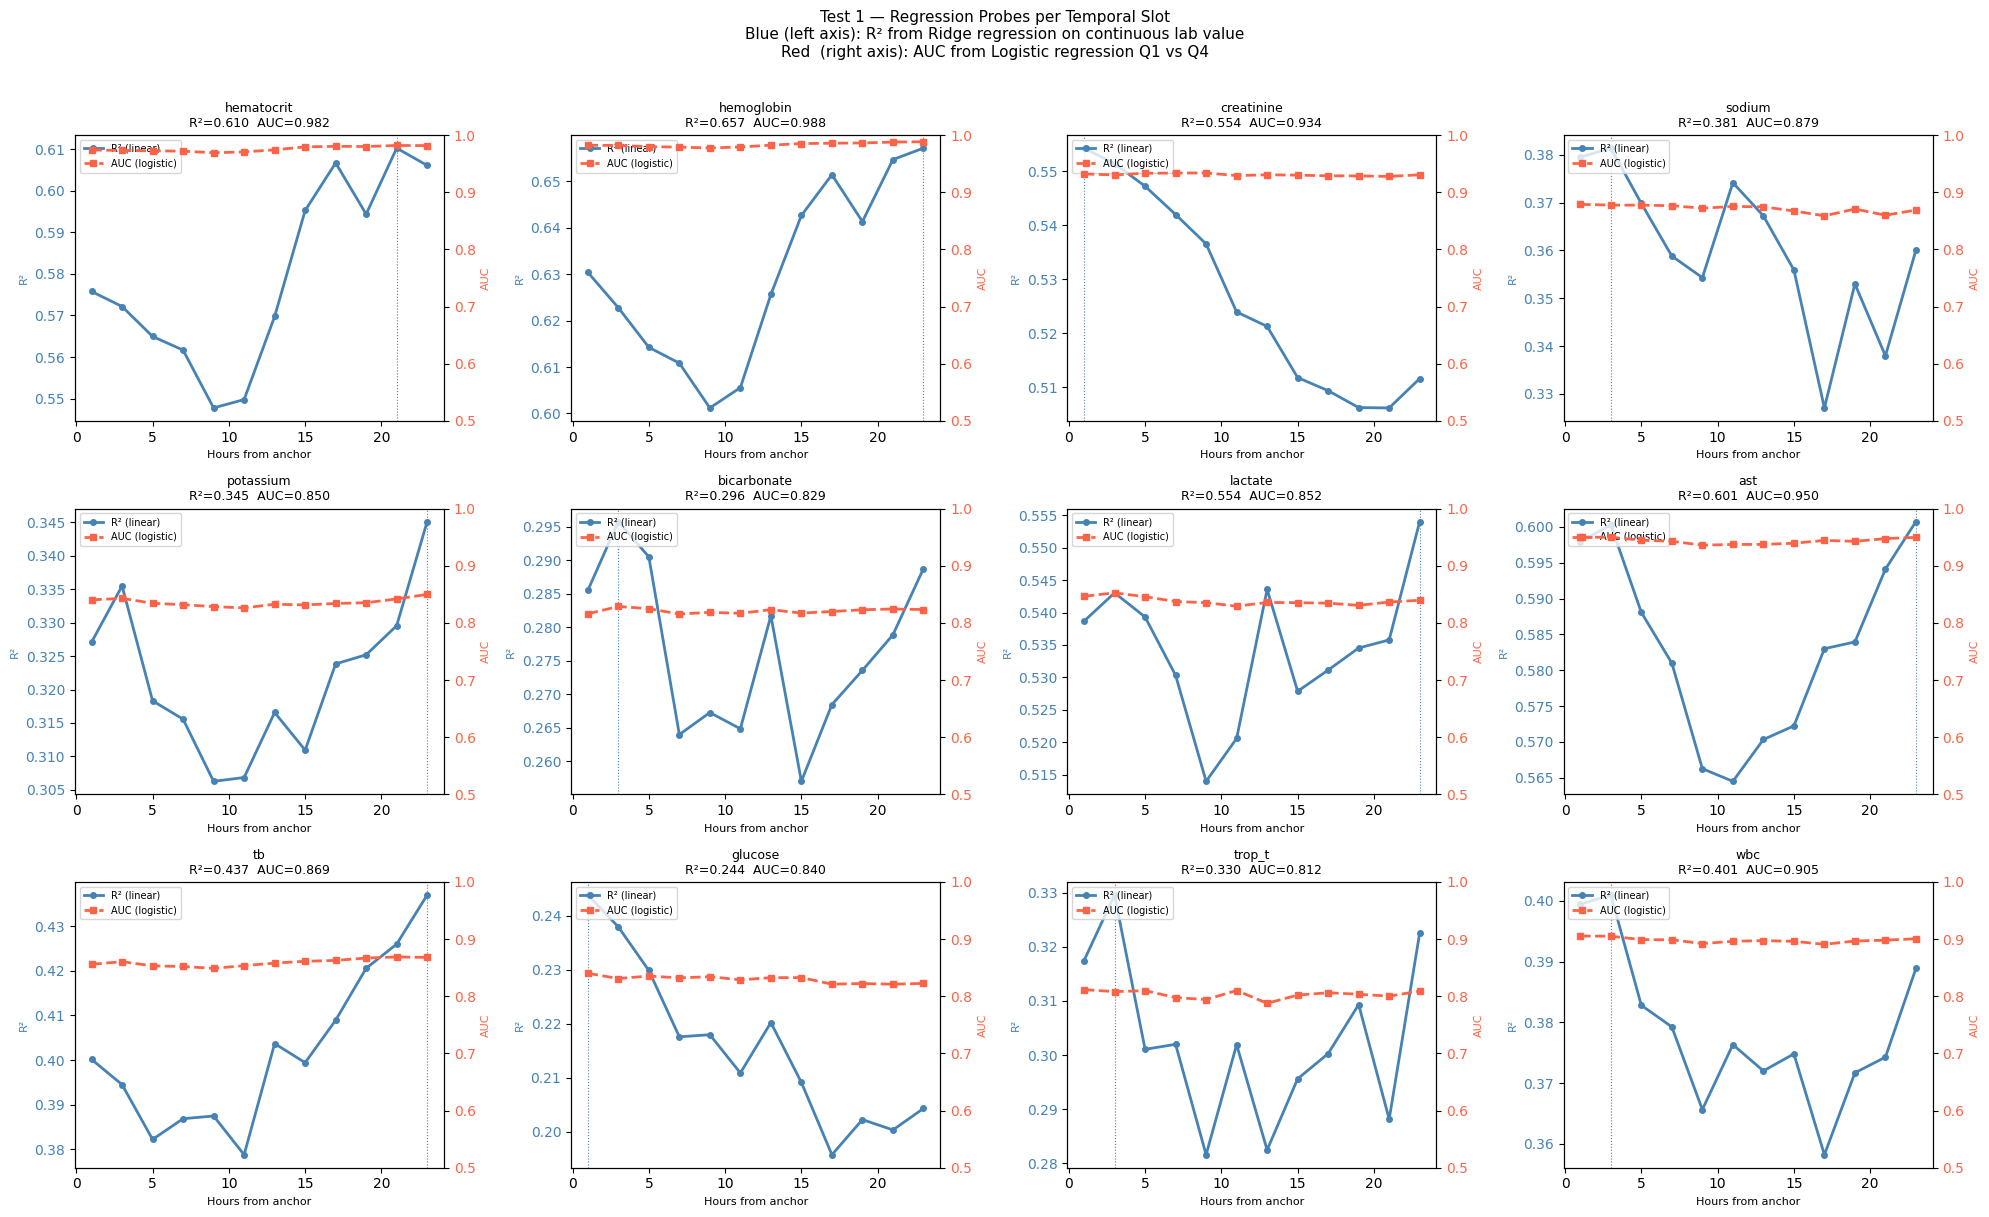

In [30]:
# ── Plot: R² and AUC over time per lab ──────────────────────────────────────
n_labs = len(labs)
n_cols = 4
n_rows = int(np.ceil(n_labs / n_cols))

# labs_to_plots = ['hematocrit', 'hemoglobin', 'creatinine']

# labs_filtered = [lab for lab in labs if lab["name"] in labs_to_plots]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=False)
axes_flat = np.array(axes).flatten()

for ax, lab in zip(axes_flat, labs):
    ax2 = ax.twinx()

    l1, = ax.plot(TC_T, lab["r2_t"],  color="steelblue", lw=2, marker="o", ms=4, label="R² (linear)")
    l2, = ax2.plot(TC_T, lab["auc_t"], color="tomato",    lw=2, marker="s", ms=4, ls="--", label="AUC (logistic)")

    ax.set_xlabel("Hours from anchor", fontsize=8)
    ax.set_ylabel("R²", color="steelblue", fontsize=8)
    ax2.set_ylabel("AUC", color="tomato", fontsize=8)
    ax.tick_params(axis="y", labelcolor="steelblue")
    ax2.tick_params(axis="y", labelcolor="tomato")
    ax2.set_ylim(0.5, 1.0)

    best_r2_t  = TC_T[lab["r2_t"].argmax()]
    best_auc_t = TC_T[lab["auc_t"].argmax()]
    ax.axvline(best_r2_t,  color="steelblue", lw=0.8, ls=":")
    # ax2.axvline(best_auc_t, color="tomato",    lw=0.8, ls=":")

    ax.set_title(
        f"{lab['name']}\nR²={lab['r2_t'].max():.3f}  AUC={lab['auc_t'].max():.3f}",
        fontsize=9,
    )
    ax.legend(handles=[l1, l2], fontsize=7, loc="upper left")

for ax in axes_flat[n_labs:]:
    ax.set_visible(False)

fig.suptitle(
    "Test 1 — Regression Probes per Temporal Slot\n"
    "Blue (left axis): R² from Ridge regression on continuous lab value\n"
    "Red  (right axis): AUC from Logistic regression Q1 vs Q4",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "test1_probes_per_slot.png", dpi=150, bbox_inches="tight")
plt.show()

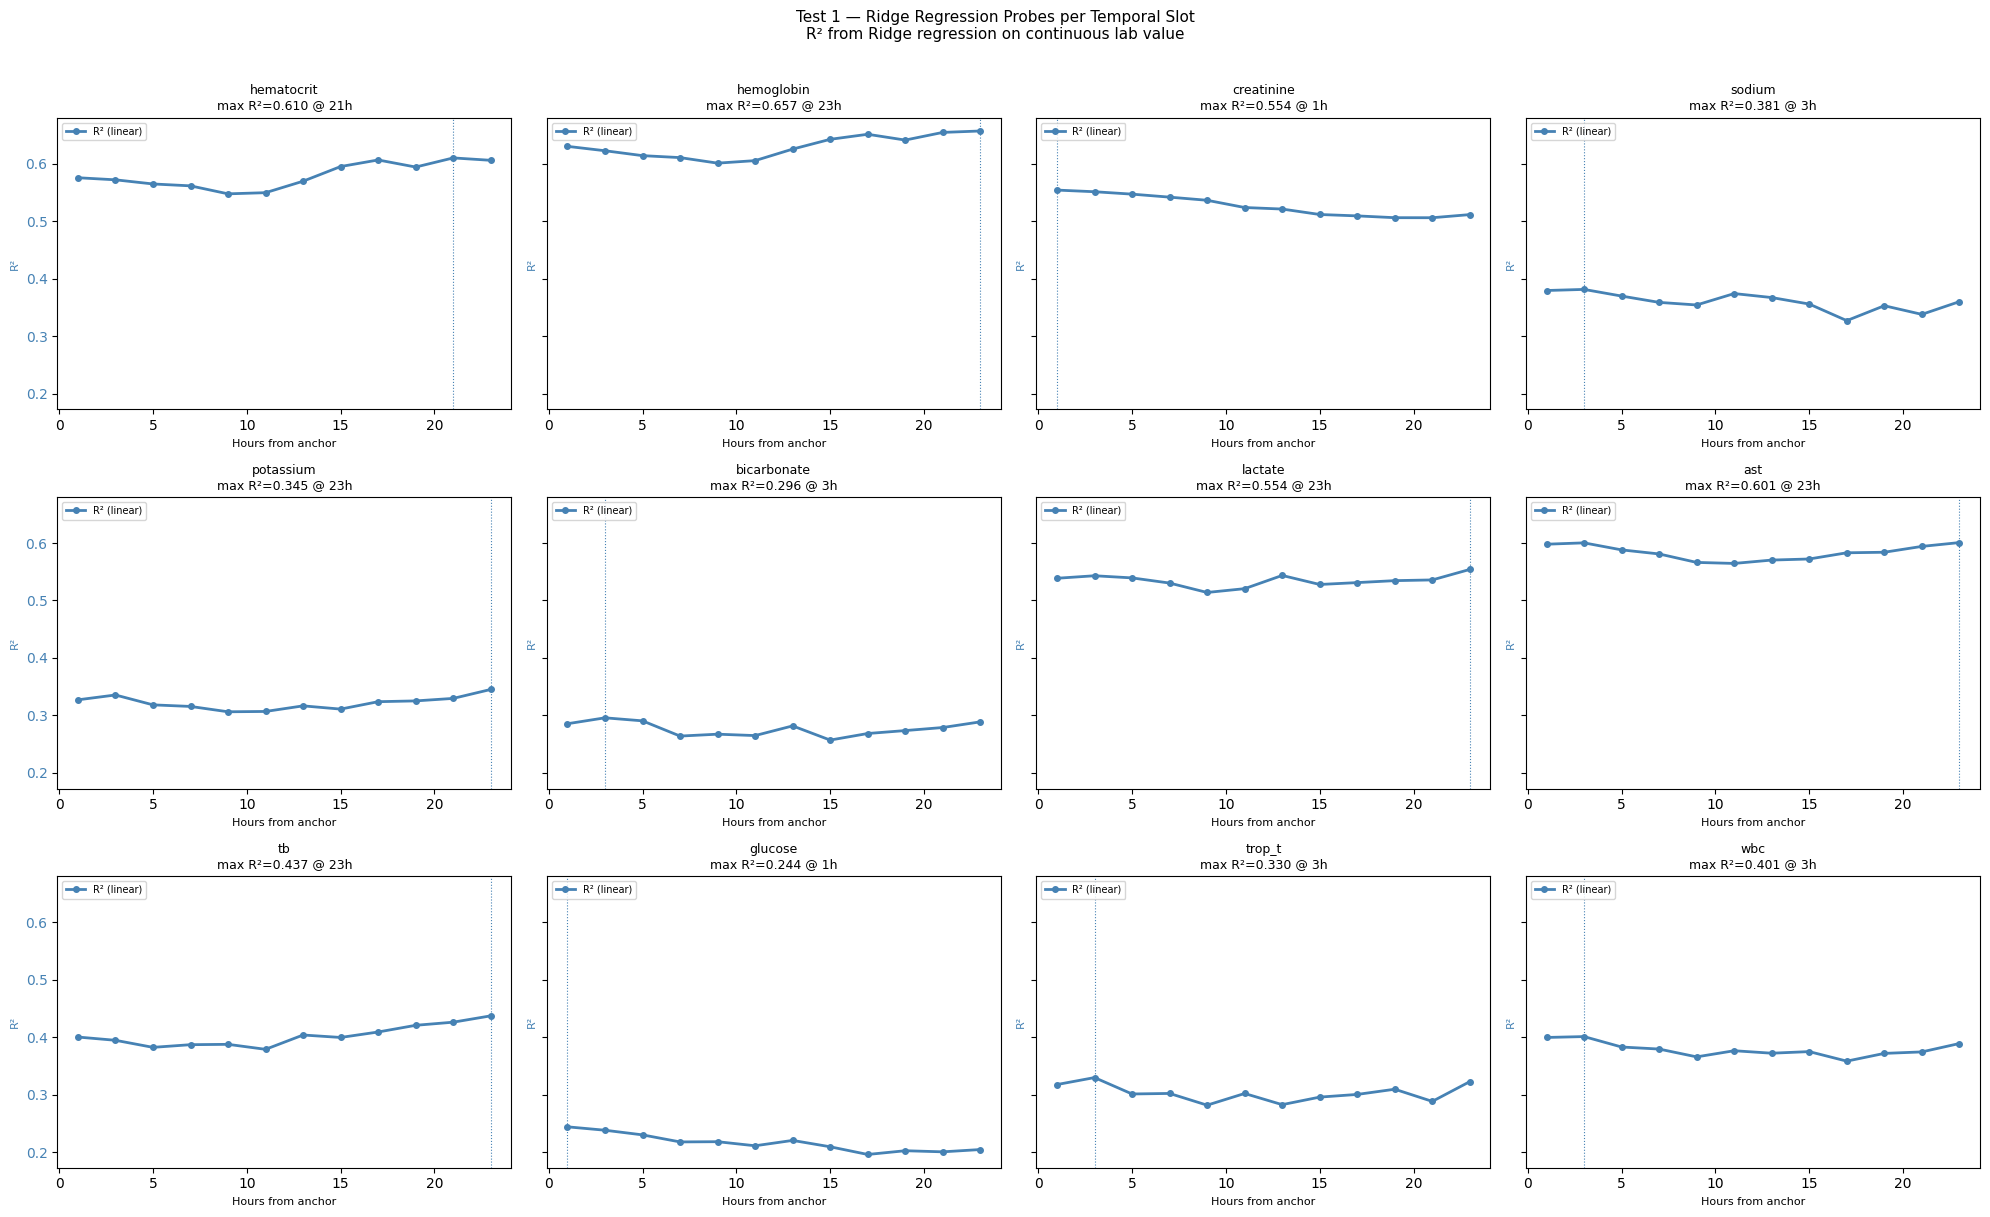

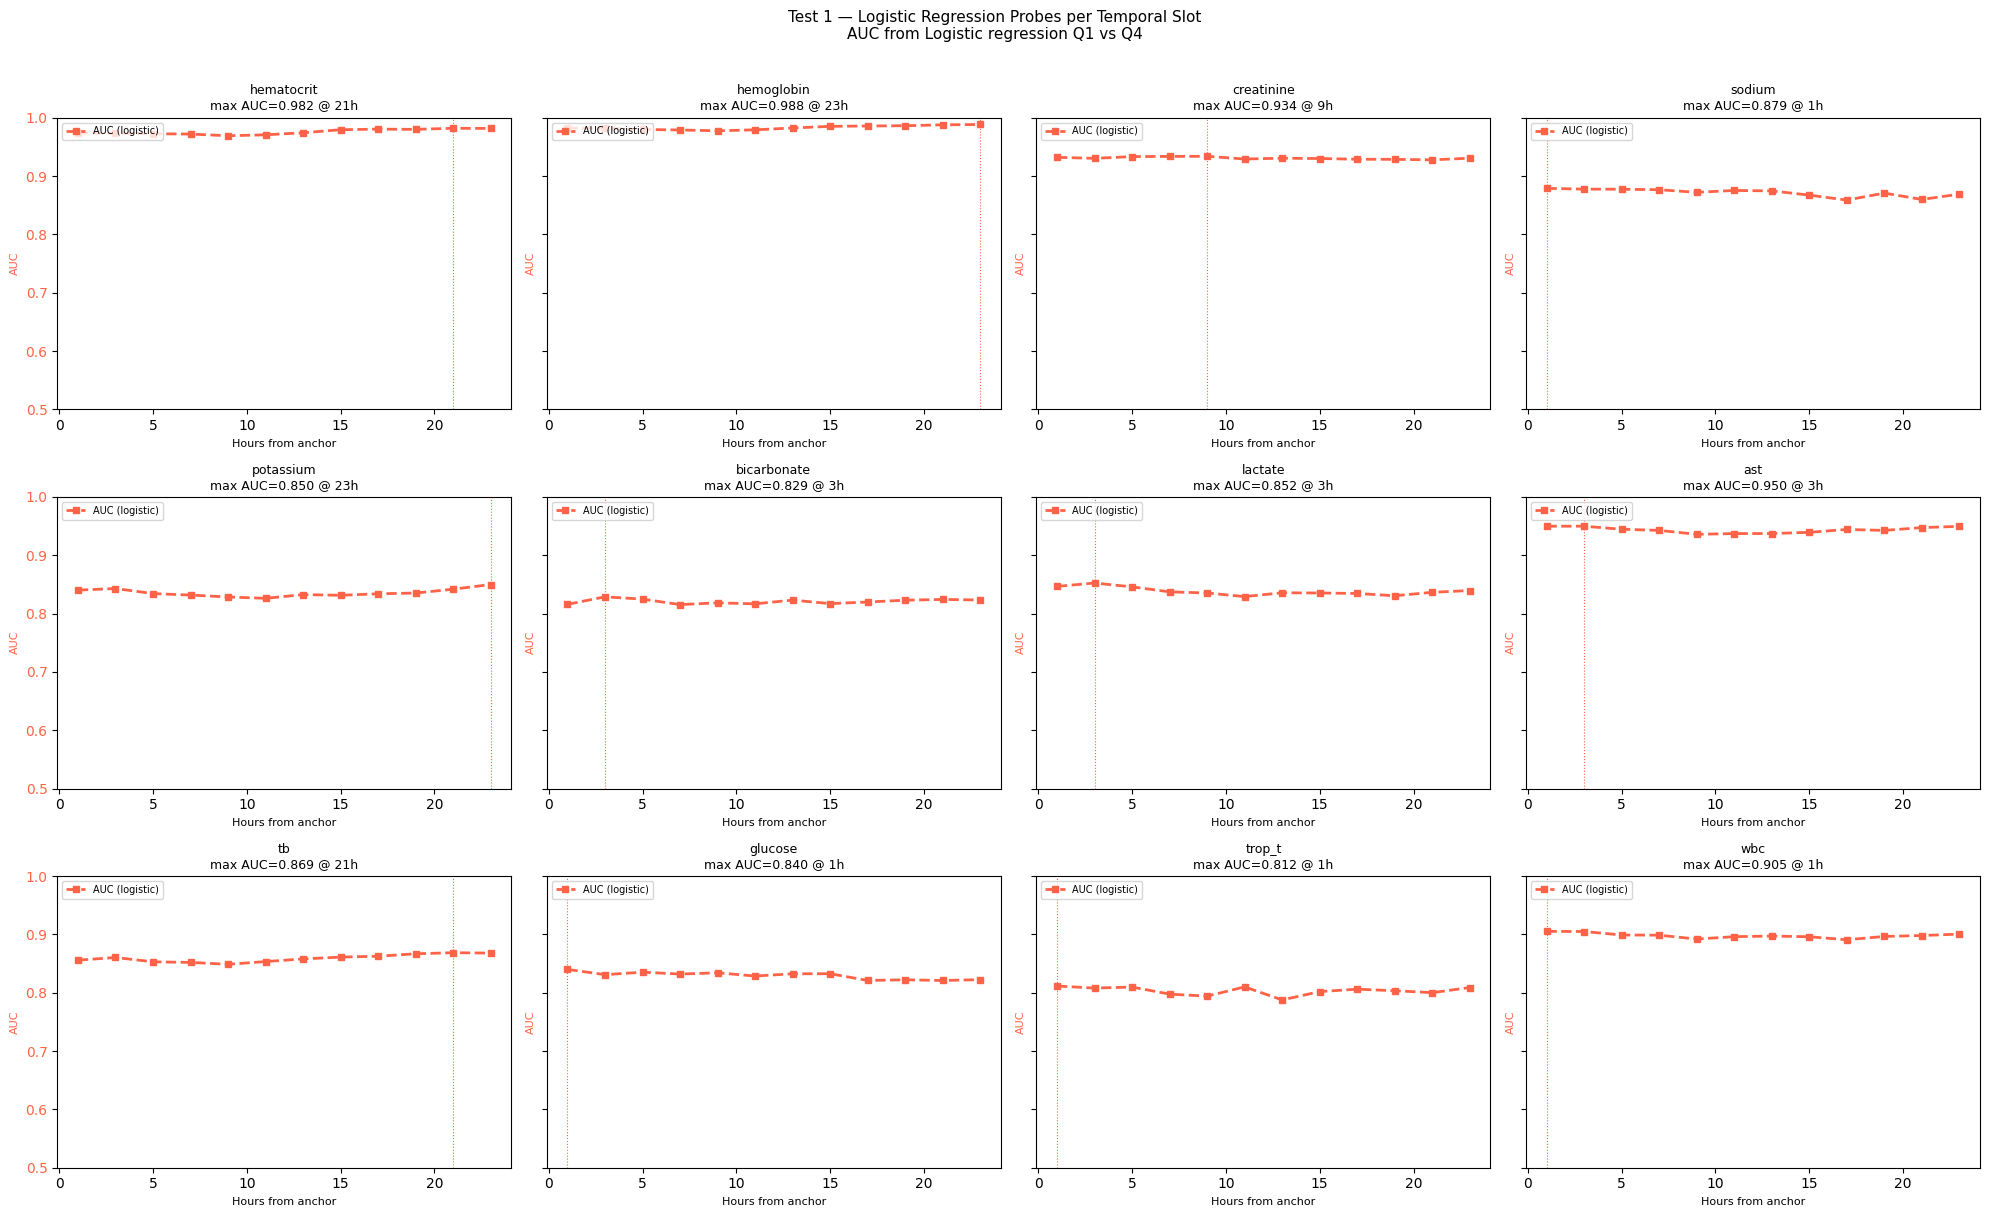

In [31]:
# ── Plot: R² and AUC over time per lab (separate figures) ──────────────────
n_labs = len(labs)
n_cols = 4
n_rows = int(np.ceil(n_labs / n_cols))

# ── Figure 1: R² (Ridge regression) ────────────────────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
axes_flat = np.array(axes).flatten()

for ax, lab in zip(axes_flat, labs):
    ax.plot(TC_T, lab["r2_t"], color="steelblue", lw=2, marker="o", ms=4, label="R² (linear)")

    best_r2_t = TC_T[lab["r2_t"].argmax()]
    ax.axvline(best_r2_t, color="steelblue", lw=0.8, ls=":")

    ax.set_xlabel("Hours from anchor", fontsize=8)
    ax.set_ylabel("R²", color="steelblue", fontsize=8)
    ax.tick_params(axis="y", labelcolor="steelblue")

    ax.set_title(
        f"{lab['name']}\nmax R²={lab['r2_t'].max():.3f} @ {best_r2_t:g}h",
        fontsize=9,
    )
    ax.legend(fontsize=7, loc="upper left")

for ax in axes_flat[n_labs:]:
    ax.set_visible(False)

fig.suptitle(
    "Test 1 — Ridge Regression Probes per Temporal Slot\n"
    "R² from Ridge regression on continuous lab value",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "test1_probes_r2_per_slot.png", dpi=150, bbox_inches="tight")
plt.show()


# ── Figure 2: AUC (Logistic regression Q1 vs Q4) ───────────────────────────
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharey=True)
axes_flat = np.array(axes).flatten()

for ax, lab in zip(axes_flat, labs):
    ax.plot(TC_T, lab["auc_t"], color="tomato", lw=2, marker="s", ms=4, ls="--", label="AUC (logistic)")

    best_auc_t = TC_T[lab["auc_t"].argmax()]
    ax.axvline(best_auc_t, color="tomato", lw=0.8, ls=":")

    ax.set_xlabel("Hours from anchor", fontsize=8)
    ax.set_ylabel("AUC", color="tomato", fontsize=8)
    ax.tick_params(axis="y", labelcolor="tomato")
    ax.set_ylim(0.5, 1.0)

    ax.set_title(
        f"{lab['name']}\nmax AUC={lab['auc_t'].max():.3f} @ {best_auc_t:g}h",
        fontsize=9,
    )
    ax.legend(fontsize=7, loc="upper left")

for ax in axes_flat[n_labs:]:
    ax.set_visible(False)

fig.suptitle(
    "Test 1 — Logistic Regression Probes per Temporal Slot\n"
    "AUC from Logistic regression Q1 vs Q4",
    y=1.01, fontsize=11,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "test1_probes_auc_per_slot.png", dpi=150, bbox_inches="tight")
plt.show()

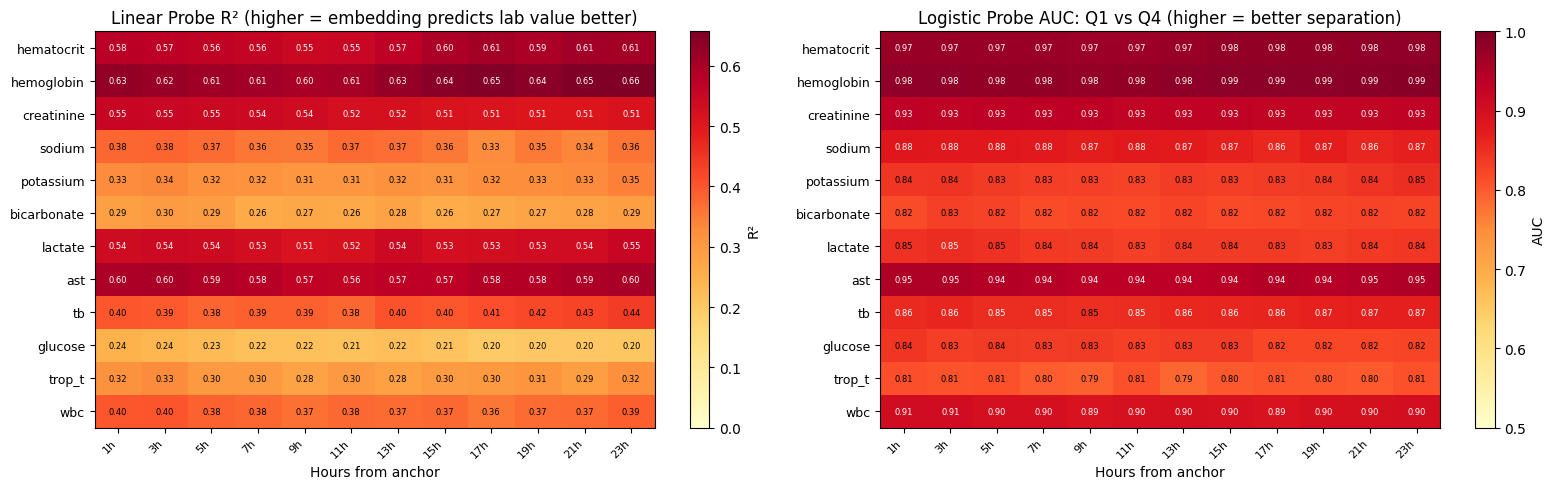


Test 1 Summary (sorted by max AUC):
        lab  max_R2  best_R2_h  mean_R2  max_AUC  best_AUC_h  mean_AUC
 hemoglobin  0.6572    23.0000   0.6298   0.9884     23.0000    0.9830
 hematocrit  0.6103    21.0000   0.5796   0.9819     21.0000    0.9758
        ast  0.6008    23.0000   0.5835   0.9498      3.0000    0.9434
 creatinine  0.5543     1.0000   0.5268   0.9339      9.0000    0.9308
        wbc  0.4010     3.0000   0.3787   0.9053      1.0000    0.8980
     sodium  0.3814     3.0000   0.3599   0.8789      1.0000    0.8715
         tb  0.4370    23.0000   0.4021   0.8687     21.0000    0.8591
    lactate  0.5540    23.0000   0.5344   0.8524      3.0000    0.8382
  potassium  0.3451    23.0000   0.3217   0.8498     23.0000    0.8357
    glucose  0.2439     1.0000   0.2159   0.8402      1.0000    0.8295
bicarbonate  0.2958     3.0000   0.2763   0.8287      3.0000    0.8208
     trop_t  0.3296     3.0000   0.3027   0.8116      1.0000    0.8033


In [32]:
# ── Heatmaps: R² and AUC across labs × time slots ───────────────────────────
lab_names_display = [l["name"] for l in labs]
r2_matrix  = np.stack([l["r2_t"]  for l in labs])   # (n_labs, T)
auc_matrix = np.stack([l["auc_t"] for l in labs])   # (n_labs, T)

time_labels = [f"{int(h)}h" for h in TC_T]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im0 = axes[0].imshow(r2_matrix, aspect="auto", cmap="YlOrRd",
                     vmin=0, vmax=max(r2_matrix.max(), 0.01))
plt.colorbar(im0, ax=axes[0], label="R²")
axes[0].set_xticks(range(T_SLOTS))
axes[0].set_xticklabels(time_labels, rotation=45, ha="right", fontsize=8)
axes[0].set_yticks(range(n_labs))
axes[0].set_yticklabels(lab_names_display, fontsize=9)
for i in range(n_labs):
    for j in range(T_SLOTS):
        axes[0].text(j, i, f"{r2_matrix[i, j]:.2f}",
                     ha="center", va="center", fontsize=6,
                     color="white" if r2_matrix[i, j] > r2_matrix.max() * 0.7 else "black")
axes[0].set(title="Linear Probe R² (higher = embedding predicts lab value better)",
            xlabel="Hours from anchor")

im1 = axes[1].imshow(auc_matrix, aspect="auto", cmap="YlOrRd", vmin=0.5, vmax=1.0)
plt.colorbar(im1, ax=axes[1], label="AUC")
axes[1].set_xticks(range(T_SLOTS))
axes[1].set_xticklabels(time_labels, rotation=45, ha="right", fontsize=8)
axes[1].set_yticks(range(n_labs))
axes[1].set_yticklabels(lab_names_display, fontsize=9)
for i in range(n_labs):
    for j in range(T_SLOTS):
        axes[1].text(j, i, f"{auc_matrix[i, j]:.2f}",
                     ha="center", va="center", fontsize=6,
                     color="white" if auc_matrix[i, j] > 0.85 else "black")
axes[1].set(title="Logistic Probe AUC: Q1 vs Q4 (higher = better separation)",
            xlabel="Hours from anchor")

plt.tight_layout()
plt.savefig(OUT_DIR / "test1_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary table
summary_t1 = pd.DataFrame({
    "lab":          lab_names_display,
    "max_R2":       r2_matrix.max(axis=1),
    "best_R2_h":    TC_T[r2_matrix.argmax(axis=1)],
    "mean_R2":      r2_matrix.mean(axis=1),
    "max_AUC":      auc_matrix.max(axis=1),
    "best_AUC_h":   TC_T[auc_matrix.argmax(axis=1)],
    "mean_AUC":     auc_matrix.mean(axis=1),
}).sort_values("max_AUC", ascending=False)

summary_t1.to_csv(OUT_DIR / "test1_summary.csv", index=False)
print("\nTest 1 Summary (sorted by max AUC):")
print(summary_t1.to_string(index=False, float_format="%.4f"))

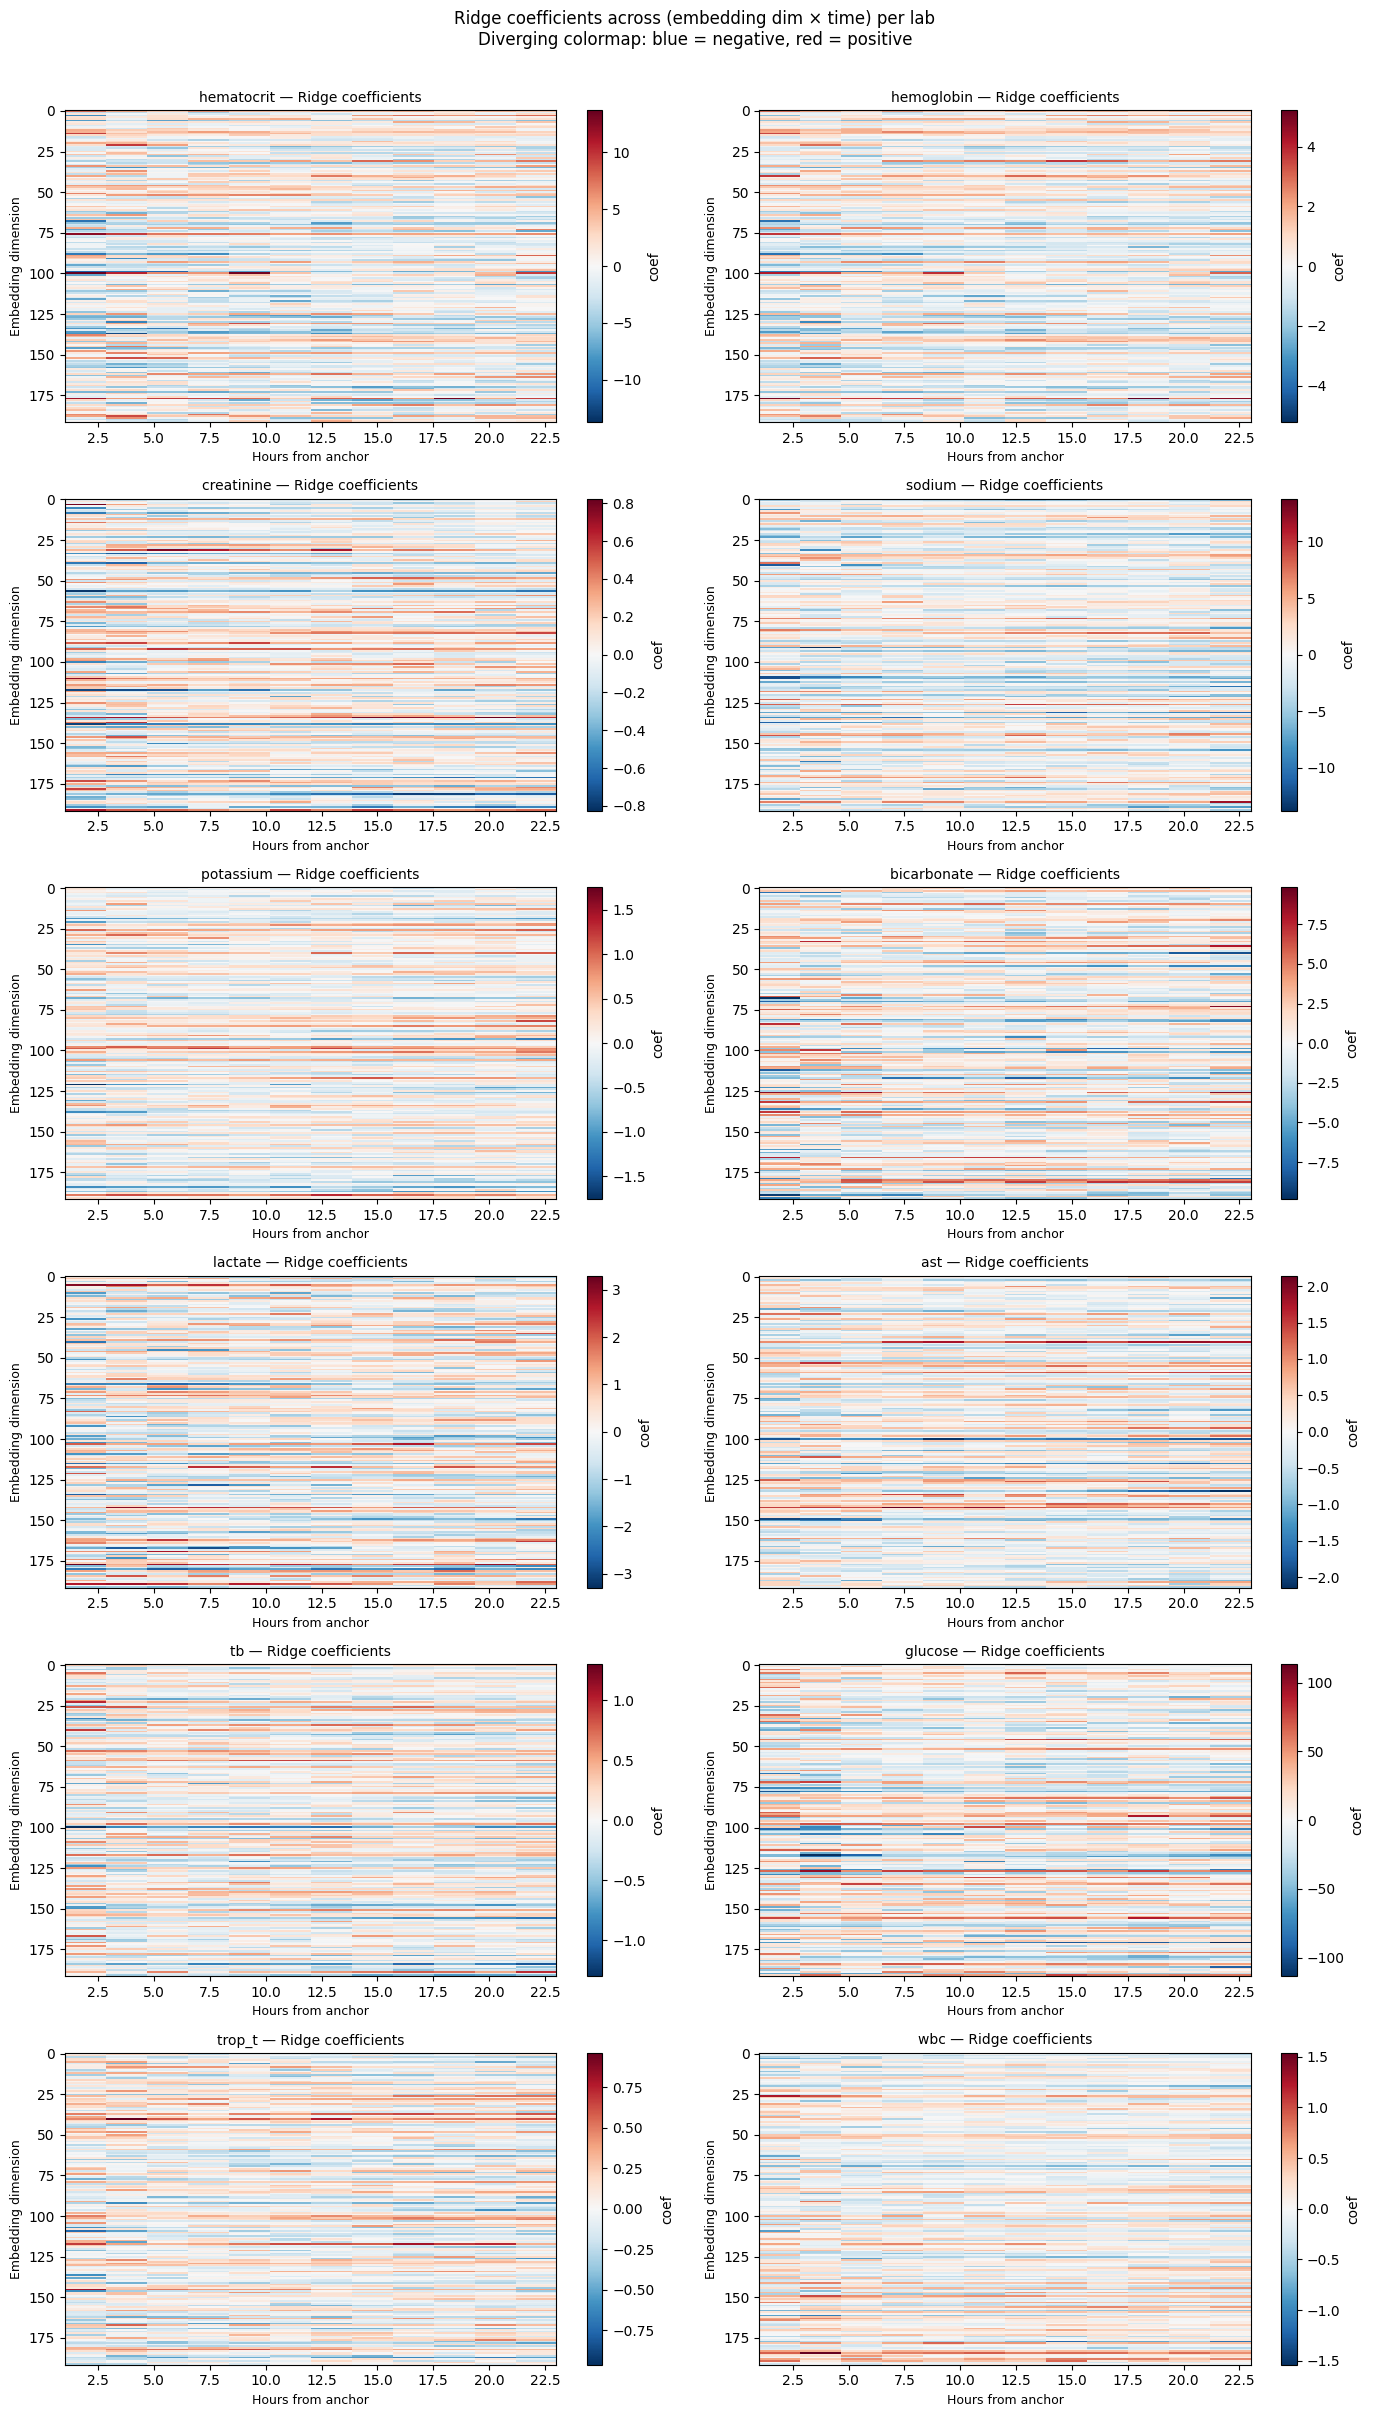

In [33]:
# ── Heatmap: coefficient magnitude across (dimension, time) per lab ─────────
n_labs = len(labs)
n_cols = 2
n_rows = int(np.ceil(n_labs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
axes_flat = np.array(axes).flatten()

for ax, lab in zip(axes_flat, labs):
    coefs = lab["ridge_coefs_t"]  # shape (T, D)
    # Transpose so rows = dimensions, cols = time
    M = coefs.T  # shape (D, T)

    vmax = np.abs(M).max()
    im = ax.imshow(
        M, aspect="auto", cmap="RdBu_r",
        vmin=-vmax, vmax=vmax,
        extent=[TC_T[0], TC_T[-1], M.shape[0] - 0.5, -0.5],
        interpolation="nearest",
    )
    ax.set_xlabel("Hours from anchor", fontsize=9)
    ax.set_ylabel("Embedding dimension", fontsize=9)
    ax.set_title(f"{lab['name']} — Ridge coefficients", fontsize=10)
    plt.colorbar(im, ax=ax, label="coef")

for ax in axes_flat[n_labs:]:
    ax.set_visible(False)

fig.suptitle(
    "Ridge coefficients across (embedding dim × time) per lab\n"
    "Diverging colormap: blue = negative, red = positive",
    y=1.005, fontsize=12,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "test1_ridge_coef_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

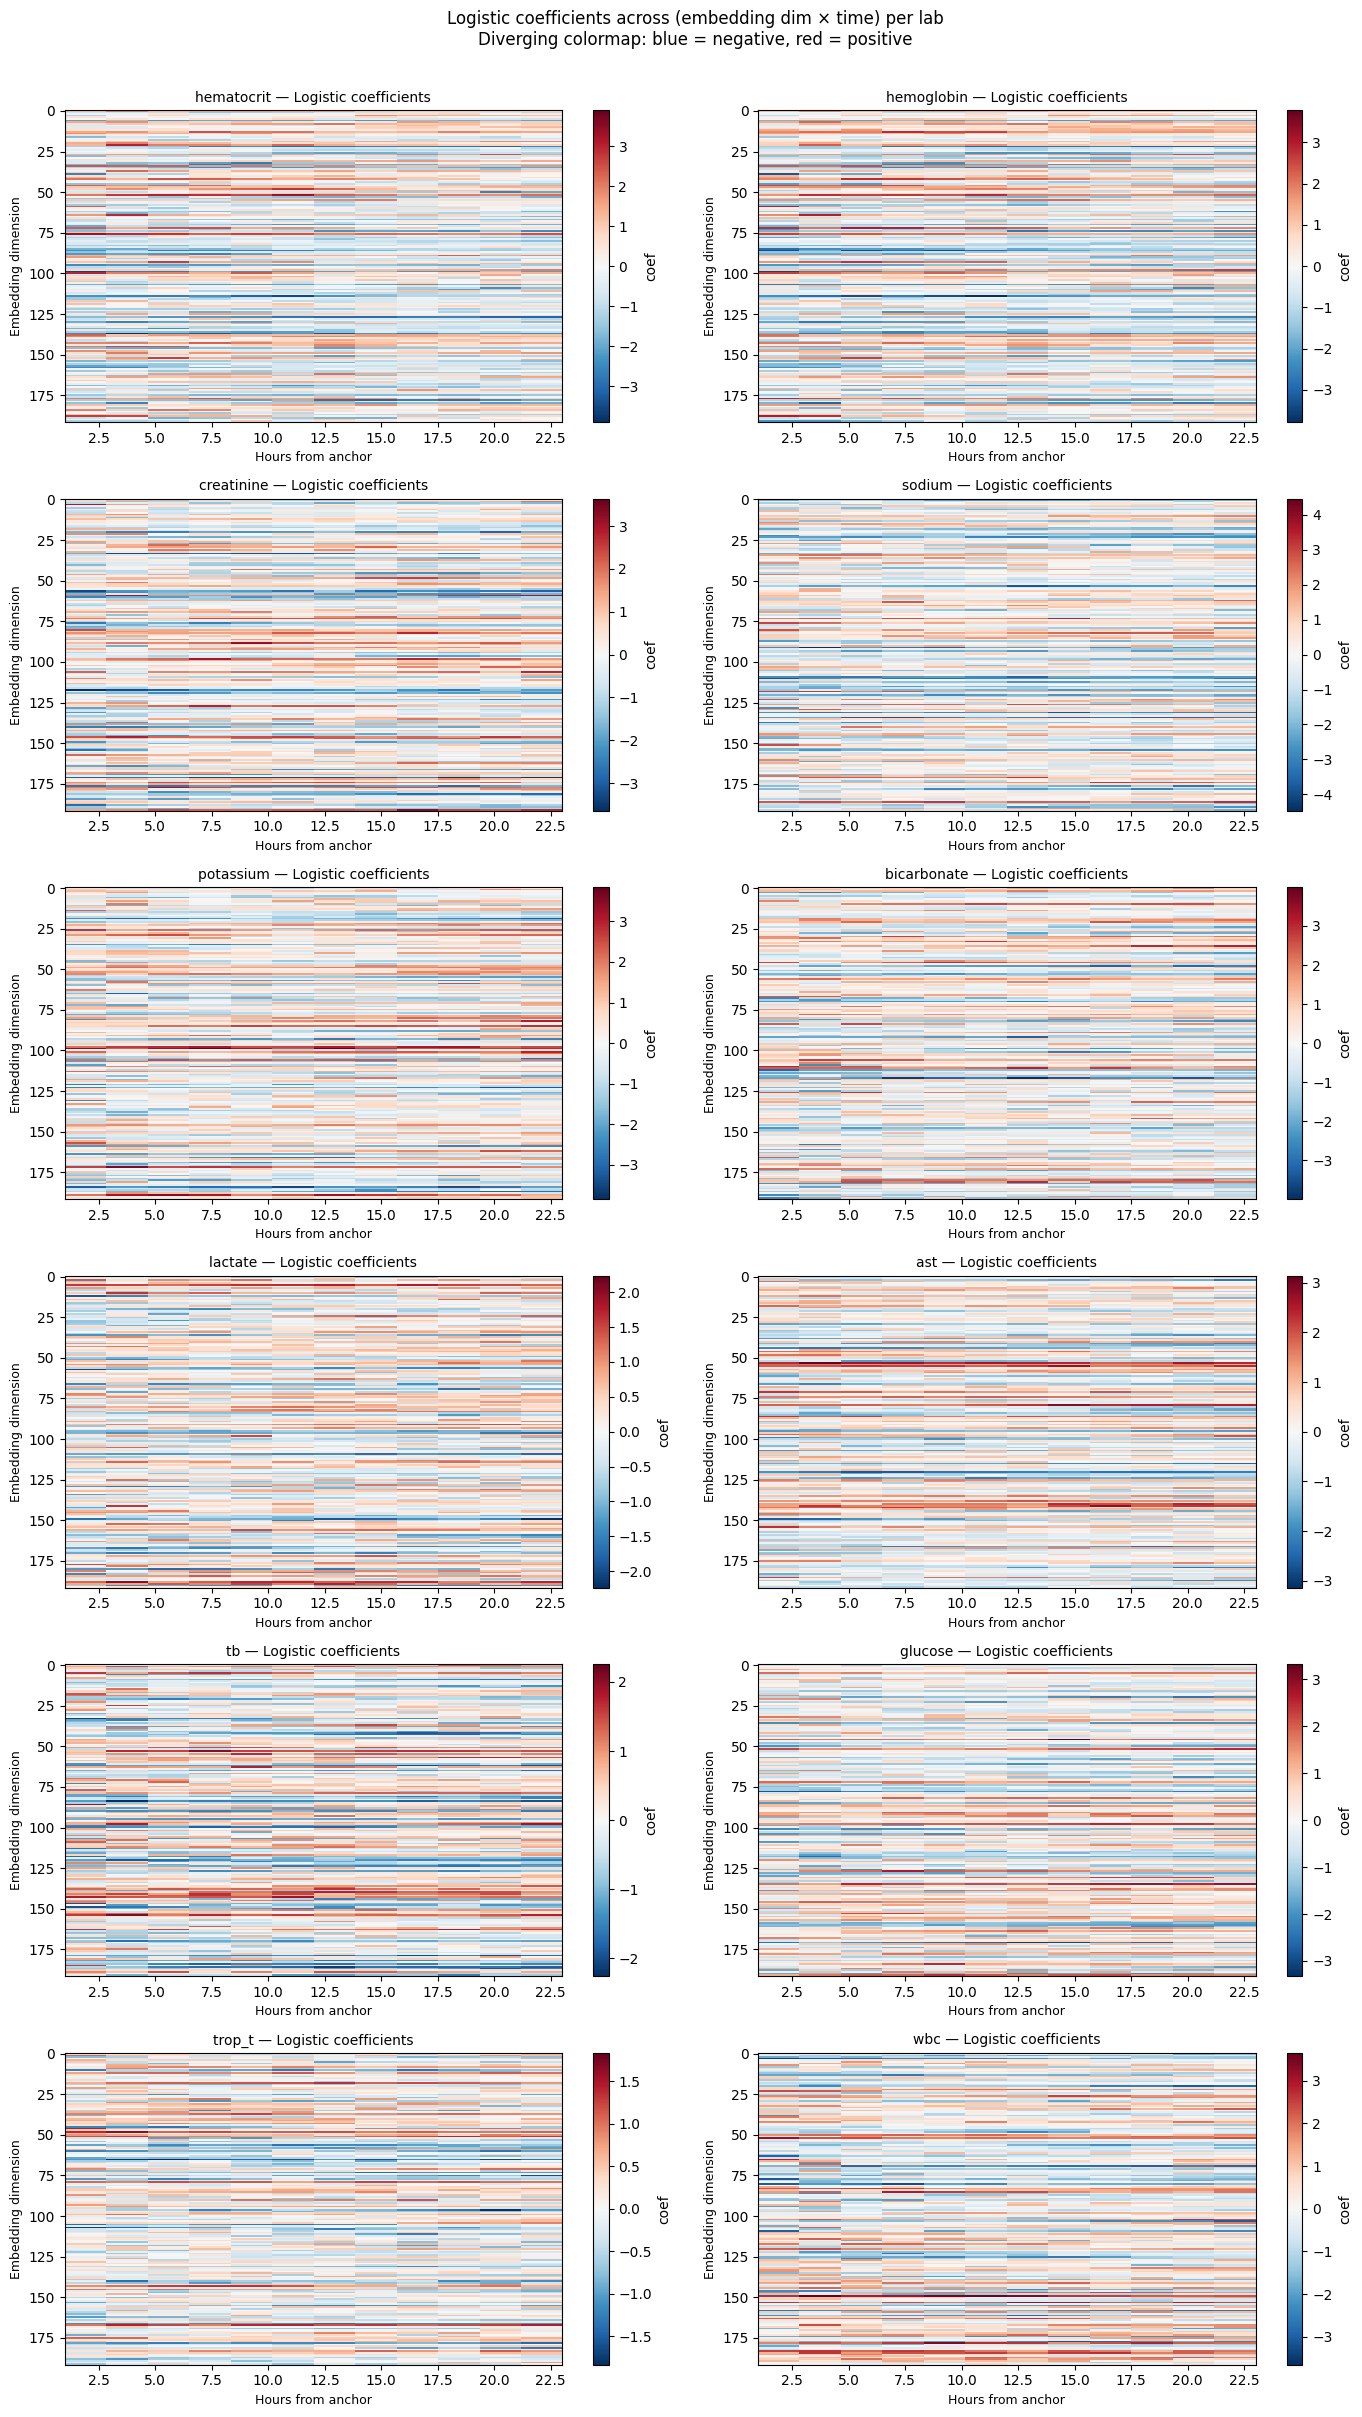

In [34]:
# ── Heatmap: coefficient magnitude across (dimension, time) per lab ─────────
n_labs = len(labs)
n_cols = 2
n_rows = int(np.ceil(n_labs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4 * n_rows))
axes_flat = np.array(axes).flatten()

for ax, lab in zip(axes_flat, labs):
    coefs = lab["logistic_coefs_t"]  # shape (T, D)
    # Transpose so rows = dimensions, cols = time
    M = coefs.T  # shape (D, T)

    vmax = np.abs(M).max()
    im = ax.imshow(
        M, aspect="auto", cmap="RdBu_r",
        vmin=-vmax, vmax=vmax,
        extent=[TC_T[0], TC_T[-1], M.shape[0] - 0.5, -0.5],
        interpolation="nearest",
    )
    ax.set_xlabel("Hours from anchor", fontsize=9)
    ax.set_ylabel("Embedding dimension", fontsize=9)
    ax.set_title(f"{lab['name']} — Logistic coefficients", fontsize=10)
    plt.colorbar(im, ax=ax, label="coef")

for ax in axes_flat[n_labs:]:
    ax.set_visible(False)

fig.suptitle(
    "Logistic coefficients across (embedding dim × time) per lab\n"
    "Diverging colormap: blue = negative, red = positive",
    y=1.005, fontsize=12,
)
plt.tight_layout()
plt.savefig(OUT_DIR / "test1_logistic_coef_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
# ── Build (labs × dims) matrix of importance ─────────────────────────────

def get_mean_coefs(labs, coef_key="ridge_coefs_t"):
    rows = [lab[coef_key].mean(axis=0) for lab in labs]
    return np.stack(rows)  # (n_labs, D)

M_mean = get_mean_coefs(labs)               # unsigned, averaged
lab_names = [lab["name"] for lab in labs]

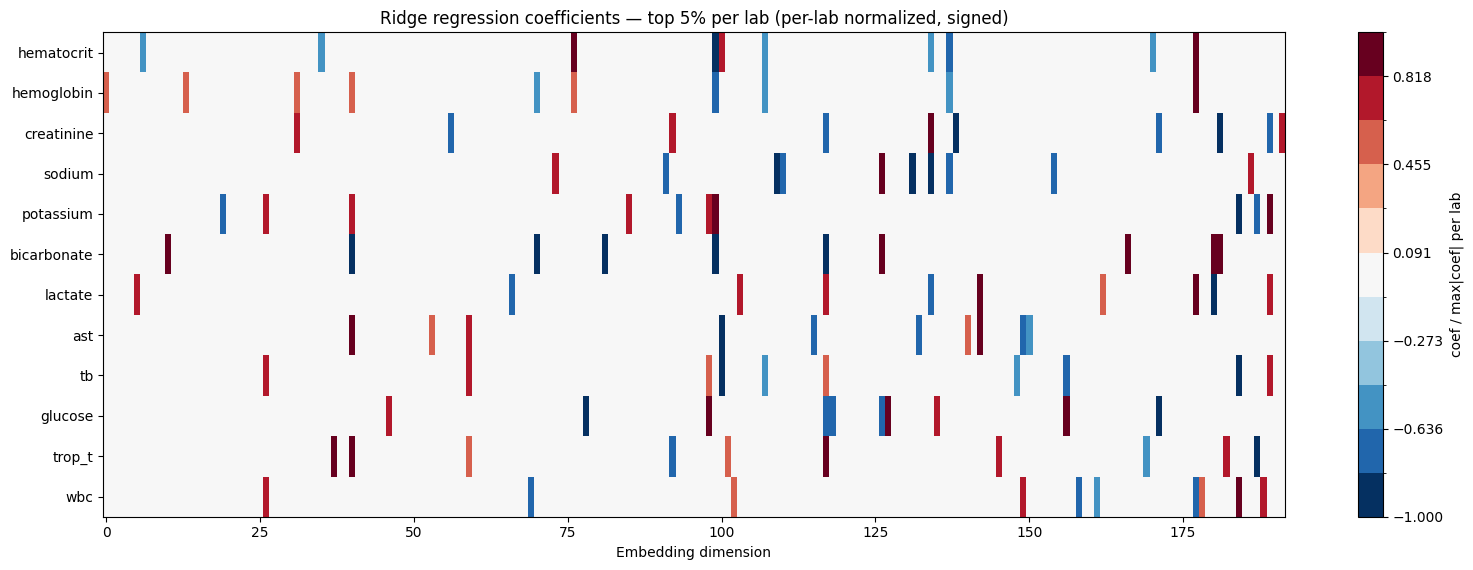

In [36]:
from matplotlib.colors import BoundaryNorm

fig, ax = plt.subplots(1, 1, figsize=(16, 1 + 0.4 * len(labs)))

M = M_mean  # (n_labs, D) — original coefficients

# 1. Normalize per lab so they're on the same scale
M_norm = M / np.abs(M).max(axis=1, keepdims=True)   # each row now in [-1, 1]

# 2. Per-lab top-5% mask (applied to the normalized matrix)
thresholds = np.percentile(np.abs(M_norm), 95, axis=1)   # (n_labs,)
mask = np.abs(M_norm) >= thresholds[:, None]
M_plot = np.where(mask, M_norm, 0.0)

# 3. Shared colorbar — now meaningful because all rows are on [-1, 1]
vmax = 1.0
cmap = plt.get_cmap("RdBu_r", 11)
norm = BoundaryNorm(np.linspace(-vmax, vmax, 12), cmap.N)

im = ax.imshow(M_plot, aspect="auto", cmap=cmap, norm=norm, interpolation="nearest")
ax.set_yticks(range(len(lab_names)))
ax.set_yticklabels(lab_names)
ax.set_xlabel("Embedding dimension")
ax.set_title("Ridge regression coefficients — top 5% per lab (per-lab normalized, signed)")
plt.colorbar(im, ax=ax, label="coef / max|coef| per lab")

# for name, row_mask in zip(lab_names, mask):
#     print(f"  {name:15s}  {row_mask.sum():3d} / {row_mask.size} dims kept")

plt.tight_layout()
plt.savefig(OUT_DIR / "test1_coef_labs_vs_dims.png", dpi=150, bbox_inches="tight")
plt.show()

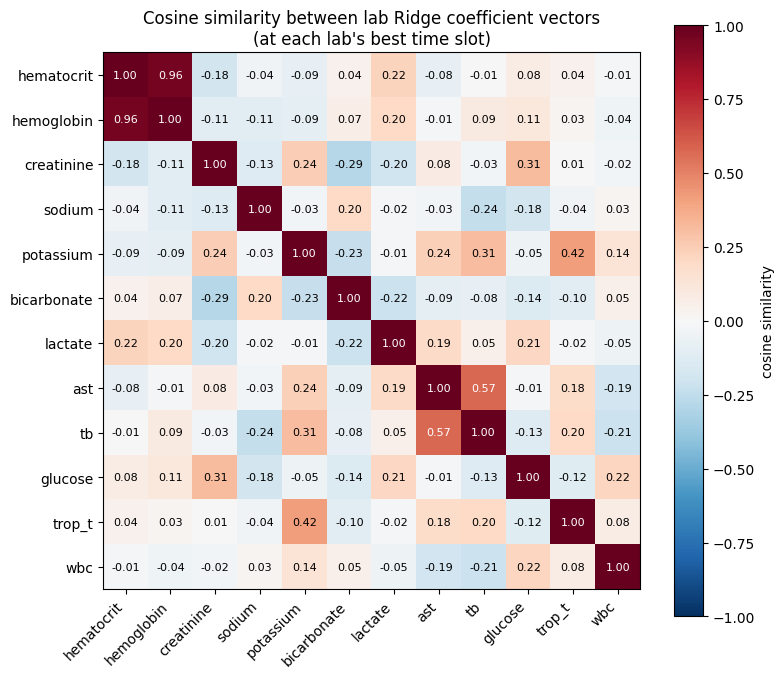

In [37]:
from scipy.spatial.distance import squareform, pdist

# Cosine similarity between labs' coefficient patterns
M = M_mean  # or M_mean — try both
sim = 1 - squareform(pdist(M, metric="cosine"))

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(sim, cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
ax.set_xticks(range(len(lab_names)))
ax.set_yticks(range(len(lab_names)))
ax.set_xticklabels(lab_names, rotation=45, ha="right")
ax.set_yticklabels(lab_names)
ax.set_title("Cosine similarity between lab Ridge coefficient vectors\n(at each lab's best time slot)")

# annotate cells
for i in range(len(lab_names)):
    for j in range(len(lab_names)):
        ax.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center",
                fontsize=8, color="black" if abs(sim[i, j]) < 0.5 else "white")

plt.colorbar(im, ax=ax, label="cosine similarity")
plt.tight_layout()
plt.savefig(OUT_DIR / "test1_lab_similarity.png", dpi=150, bbox_inches="tight")
plt.show()

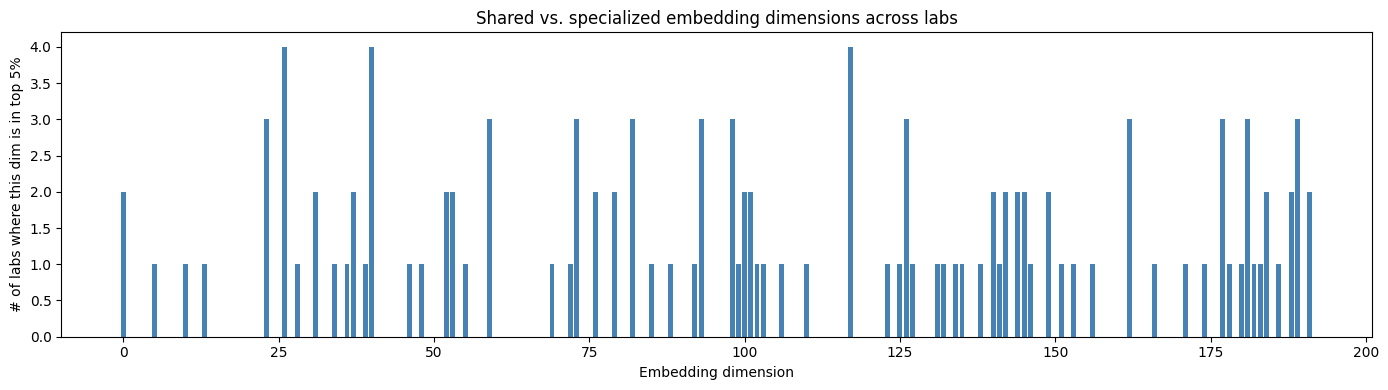

Most universally important dims:
  dim   40: used by 4 / 12 labs
  dim   26: used by 4 / 12 labs
  dim  117: used by 4 / 12 labs
  dim  189: used by 3 / 12 labs
  dim  126: used by 3 / 12 labs
  dim  181: used by 3 / 12 labs
  dim  177: used by 3 / 12 labs
  dim  162: used by 3 / 12 labs
  dim   93: used by 3 / 12 labs
  dim   98: used by 3 / 12 labs


In [38]:
# Threshold: a dim is "important" for a lab if its |coef| is in the top 5% for that lab
thresh = np.quantile(M_mean, 0.95, axis=1, keepdims=True)   # per-lab threshold
important = (M_mean >= thresh).astype(int)       # (n_labs, D), binary

n_labs_using = important.sum(axis=0)            # (D,) how many labs use each dim

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(n_labs_using)), n_labs_using, color="steelblue")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("# of labs where this dim is in top 5%")
ax.set_title("Shared vs. specialized embedding dimensions across labs")
plt.tight_layout()
plt.savefig(OUT_DIR / "test1_shared_dims.png", dpi=150, bbox_inches="tight")
plt.show()

# Print the most universal dimensions
top_shared = np.argsort(n_labs_using)[::-1][:10]
print("Most universally important dims:")
for d in top_shared:
    print(f"  dim {d:4d}: used by {n_labs_using[d]} / {len(labs)} labs")

## Test 2 — PCA Latent-Space Structure

**Per-slot PCA**: repeat the correlation check at each temporal slot `t` to see
whether certain PCs track particular labs at particular times.

In [39]:
corr_t = np.zeros((n_labs, T_SLOTS, N_PCS))

print("Running per-slot PCA...")
for t in tqdm(range(T_SLOTS), desc="Slots"):
    # All admissions, each exactly once
    X_t   = temporal_embs[:, t, :]          # (N_total, D)
    pca_t = PCA(n_components=N_PCS, random_state=SEED)
    Z_t   = pca_t.fit_transform(X_t)        # (N_total, N_PCS)

    # For each lab, index by valid_idx to get that lab's cohort
    for i, lab in enumerate(labs):
        Z_sub  = Z_t[lab["valid_idx"]]       # (n_i, N_PCS)
        vals_i = lab["all_val"]
        for pc in range(N_PCS):
            r, _ = sp_stats.spearmanr(Z_sub[:, pc], vals_i)
            corr_t[i, t, pc] = r

max_r_t = np.abs(corr_t).max(axis=2)

Running per-slot PCA...


Slots: 100%|██████████| 12/12 [00:04<00:00,  2.68it/s]


In [40]:
# # ── 2a. Per-slot PCA: Spearman r between best PC and lab value over time ──────
# # At each temporal slot t:
# #   1. Pool embeddings from all labs at slot t
# #   2. Fit PCA
# #   3. For each lab, compute max |Spearman r| over PCs
# #   4. Track which PC has highest |r| for each lab

# # Shape: (n_labs, T, N_PCS) — Spearman r at each time slot
# corr_t = np.zeros((n_labs, T_SLOTS, N_PCS))

# print("Running per-slot PCA...")
# for t in tqdm(range(T_SLOTS), desc="Slots"):
    
#     seen_ids = set()
#     rows = []
#     for l in labs:
#         for idx, hid in zip(l["valid_idx"], l["hadm_ids"]):  # need to store these
#             if hid in seen_ids:
#                 continue
#             seen_ids.add(hid)
#             rows.append(l["all_temb"][... , t, :])  # get this patient's row
#     X_t = np.vstack(rows)
#     pca_t = PCA(n_components=N_PCS, random_state=SEED)
#     Z_t   = pca_t.fit_transform(X_t)

#     offset = 0
#     for i, lab in enumerate(labs):
#         n_i     = len(lab["all_val"])
#         Z_sub   = Z_t[offset:offset + n_i]   # (N_i, N_PCS)
#         vals_i  = lab["all_val"]
#         for pc in range(N_PCS):
#             r, _ = sp_stats.spearmanr(Z_sub[:, pc], vals_i)
#             corr_t[i, t, pc] = r
#         offset += n_i

# # Max |r| over PCs at each (lab, time slot)
# max_r_t = np.abs(corr_t).max(axis=2)   # (n_labs, T)

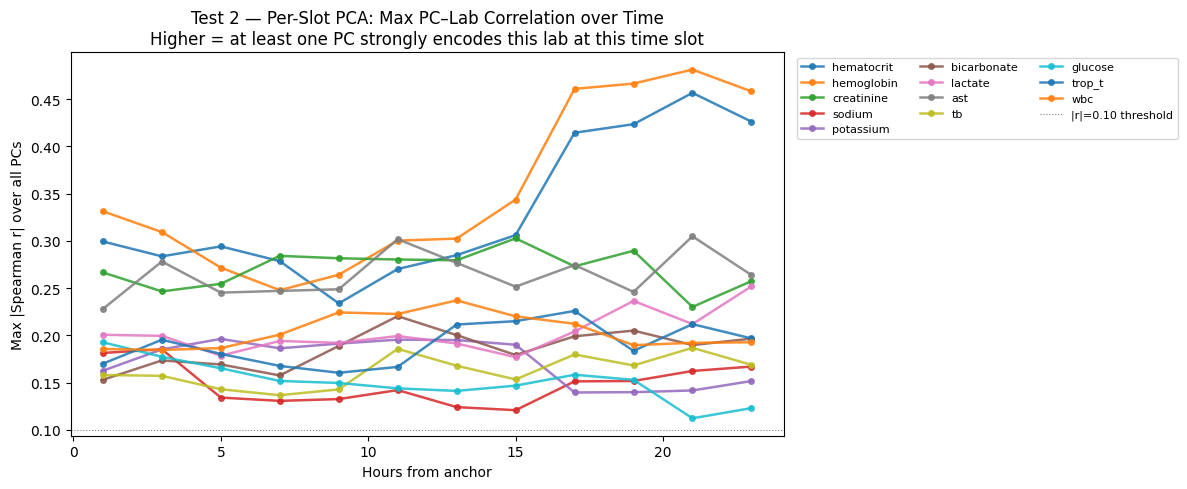

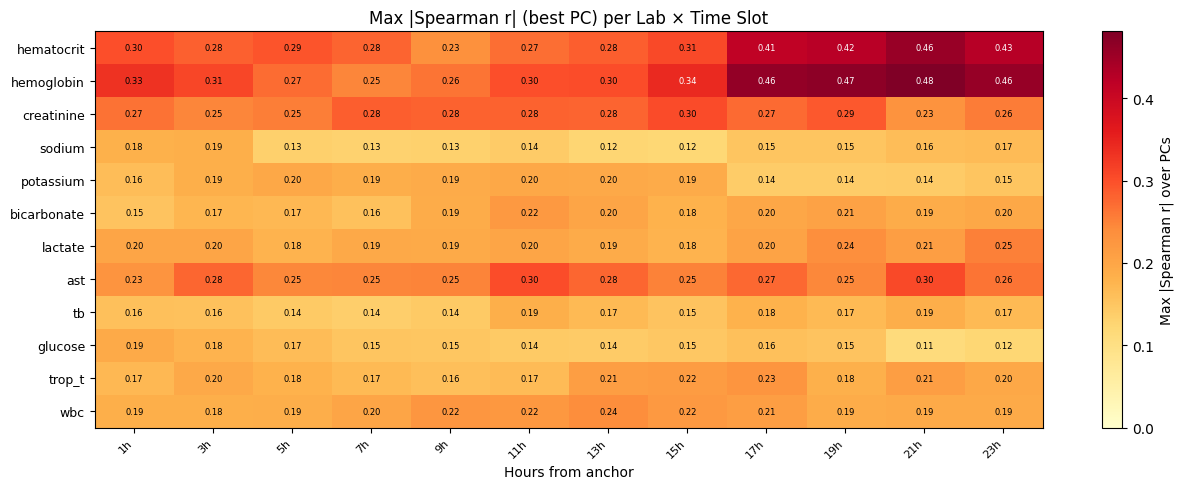

In [41]:
# ── 2e. Plot: max |Spearman r| over PCs, per lab, over time ─────────────────
fig, ax = plt.subplots(figsize=(12, 5))
for i, lab in enumerate(labs):
    ax.plot(TC_T, max_r_t[i], marker="o", ms=4, lw=1.8,
            label=lab["name"], alpha=0.85)
ax.axhline(0.1, color="gray", lw=0.8, ls=":", label="|r|=0.10 threshold")
ax.set(xlabel="Hours from anchor",
       ylabel="Max |Spearman r| over all PCs",
       title="Test 2 — Per-Slot PCA: Max PC–Lab Correlation over Time\n"
             "Higher = at least one PC strongly encodes this lab at this time slot")
ax.legend(fontsize=8, ncol=3, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUT_DIR / "test2_max_pc_corr_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

# Heatmap: (n_labs × T) of max |r|
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(max_r_t, aspect="auto", cmap="YlOrRd", vmin=0, vmax=max(max_r_t.max(), 0.01))
plt.colorbar(im, ax=ax, label="Max |Spearman r| over PCs")
ax.set_xticks(range(T_SLOTS))
ax.set_xticklabels([f"{int(h)}h" for h in TC_T], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(n_labs))
ax.set_yticklabels(lab_names_display, fontsize=9)
for i in range(n_labs):
    for j in range(T_SLOTS):
        ax.text(j, i, f"{max_r_t[i, j]:.2f}",
                ha="center", va="center", fontsize=6,
                color="white" if max_r_t[i, j] > max_r_t.max() * 0.7 else "black")
ax.set(title="Max |Spearman r| (best PC) per Lab × Time Slot",
       xlabel="Hours from anchor")
plt.tight_layout()
plt.savefig(OUT_DIR / "test2_max_pc_corr_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Peak PC encoding per lab:
Lab               Peak time   Best PC   Max |r|
--------------------------------------------------
hematocrit             21h  PC1         0.4567
hemoglobin             21h  PC1         0.4813
creatinine             15h  PC1         0.3028
sodium                  3h  PC4         0.1853
potassium               5h  PC10        0.1964
bicarbonate            11h  PC4         0.2204
lactate                23h  PC11        0.2520
ast                    21h  PC11        0.3049
tb                     21h  PC11        0.1869
glucose                 1h  PC3         0.1928
trop_t                 17h  PC12        0.2260
wbc                    13h  PC4         0.2371


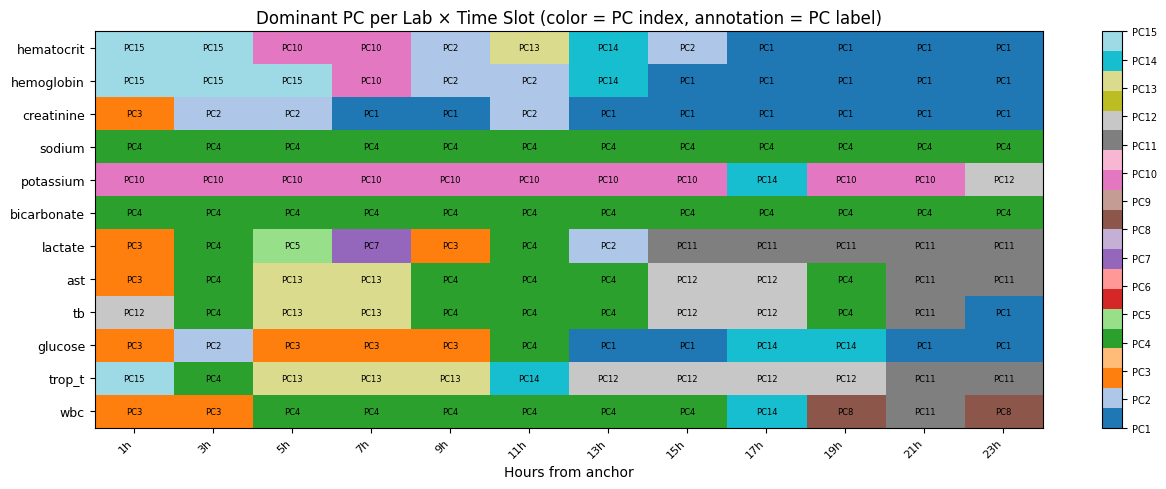

In [42]:
# ── 2b. Which PC is dominant for each lab at its peak time? ─────────────────
best_pc_t = np.abs(corr_t).argmax(axis=2)   # (n_labs, T) — best PC index per slot

# For each lab, find the time slot where max |r| is highest
peak_slot = max_r_t.argmax(axis=1)           # (n_labs,)

print("Peak PC encoding per lab:")
print(f"{'Lab':15s}  {'Peak time':>10s}  {'Best PC':>8s}  {'Max |r|':>8s}")
print("-" * 50)
for i, lab in enumerate(labs):
    t_peak  = int(peak_slot[i])
    pc_peak = int(best_pc_t[i, t_peak])
    r_peak  = float(max_r_t[i, t_peak])
    print(f"{lab['name']:15s}  {TC_T[t_peak]:>8.0f}h  PC{pc_peak+1:<6d}  {r_peak:>8.4f}")

# Visualise which PC is the dominant encoder at each slot
# Use a colour map over PC index
fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(best_pc_t, aspect="auto", cmap="tab20", vmin=0, vmax=N_PCS - 1)
cbar = plt.colorbar(im, ax=ax, ticks=range(N_PCS))
cbar.set_ticklabels([f"PC{j+1}" for j in range(N_PCS)], fontsize=7)
ax.set_xticks(range(T_SLOTS))
ax.set_xticklabels([f"{int(h)}h" for h in TC_T], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(n_labs))
ax.set_yticklabels(lab_names_display, fontsize=9)
for i in range(n_labs):
    for j in range(T_SLOTS):
        ax.text(j, i, f"PC{best_pc_t[i, j]+1}",
                ha="center", va="center", fontsize=6, color="black")
ax.set(title="Dominant PC per Lab × Time Slot (color = PC index, annotation = PC label)",
       xlabel="Hours from anchor")
plt.tight_layout()
plt.savefig(OUT_DIR / "test2_dominant_pc_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

In [43]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary_rows = []
for i, lab in enumerate(labs):
    t_peak   = int(peak_slot[i])
    pc_peak  = int(best_pc_t[i, t_peak])
    summary_rows.append({
        "lab":             lab["name"],
        # Test 1
        "T1_max_R2":       float(r2_matrix[i].max()),
        "T1_best_R2_h":    float(TC_T[r2_matrix[i].argmax()]),
        "T1_mean_R2":      float(r2_matrix[i].mean()),
        "T1_max_AUC":      float(auc_matrix[i].max()),
        "T1_best_AUC_h":   float(TC_T[auc_matrix[i].argmax()]),
        # Test 2
        # "T2_global_maxR": float(np.abs(corr_matrix[i]).max()),
        # "T2_global_bestPC": int(np.abs(corr_matrix[i]).argmax()) + 1,
        "T2_perslot_maxR": float(max_r_t[i].max()),
        "T2_peak_h":       float(TC_T[t_peak]),
        "T2_peak_PC":      pc_peak + 1,
    })

summary_df = pd.DataFrame(summary_rows).sort_values("T1_max_AUC", ascending=False)
summary_df.to_csv(OUT_DIR / "summary_all.csv", index=False)

print("=" * 80)
print("TEMPORAL EMBEDDING PROBE — SUMMARY")
print("=" * 80)
print(f"{'Lab':15s}  {'T1 max R²':>9s}  {'T1 best h':>9s}  {'T1 max AUC':>10s}  "
      f"  {'T2 slot |r|':>11s}  {'T2 peak h':>9s}")
print("-" * 80)
for _, row in summary_df.iterrows():
    print(
        f"{row['lab']:15s}  "
        f"{row['T1_max_R2']:9.4f}  "
        f"{row['T1_best_R2_h']:9.0f}h  "
        f"{row['T1_max_AUC']:10.4f}  "
        # f"{row['T2_global_maxR']:11.4f}  "
        # f"{'PC'+str(int(row['T2_global_bestPC'])):>10s}  "
        f"{row['T2_perslot_maxR']:11.4f}  "
        f"{row['T2_peak_h']:9.0f}h"
    )
print()
print(f"Output directory: {OUT_DIR}")

TEMPORAL EMBEDDING PROBE — SUMMARY
Lab              T1 max R²  T1 best h  T1 max AUC    T2 slot |r|  T2 peak h
--------------------------------------------------------------------------------
hemoglobin          0.6572         23h      0.9884       0.4813         21h
hematocrit          0.6103         21h      0.9819       0.4567         21h
ast                 0.6008         23h      0.9498       0.3049         21h
creatinine          0.5543          1h      0.9339       0.3028         15h
wbc                 0.4010          3h      0.9053       0.2371         13h
sodium              0.3814          3h      0.8789       0.1853          3h
tb                  0.4370         23h      0.8687       0.1869         21h
lactate             0.5540         23h      0.8524       0.2520         23h
potassium           0.3451         23h      0.8498       0.1964          5h
glucose             0.2439          1h      0.8402       0.1928          1h
bicarbonate         0.2958          3h      0.82